100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 230kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.2MB/s]


S.NO:1 epoch_trainloss  = 0.6997765796383222 $ epoch_val_loss = 0.5055117607116699
S.NO:2 epoch_trainloss  = 0.4715169194539388 $ epoch_val_loss = 0.4555946452186463
S.NO:3 epoch_trainloss  = 0.43360557800531385 $ epoch_val_loss = 0.44764760279275
S.NO:4 epoch_trainloss  = 0.4114286684393883 $ epoch_val_loss = 0.41638968702643475
S.NO:5 epoch_trainloss  = 0.3915464520851771 $ epoch_val_loss = 0.408759002989911
S.NO:6 epoch_trainloss  = 0.38193501681089403 $ epoch_val_loss = 0.40888556608177246
S.NO:7 epoch_trainloss  = 0.37154034662246704 $ epoch_val_loss = 0.39326605462330455
S.NO:8 epoch_trainloss  = 0.3628568799098333 $ epoch_val_loss = 0.3957398198544979
S.NO:9 epoch_trainloss  = 0.35691033377250037 $ epoch_val_loss = 0.3885772878977847
S.NO:10 epoch_trainloss  = 0.35094879162311554 $ epoch_val_loss = 0.39936266577941304
S.NO:11 epoch_trainloss  = 0.3438998454610507 $ epoch_val_loss = 0.4110752412296356
S.NO:12 epoch_trainloss  = 0.34040571235617 $ epoch_val_loss = 0.39142066985368

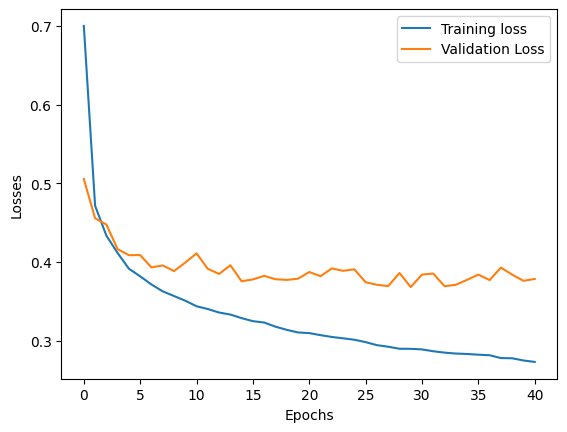

accuraacy = 85.6 % 


In [1]:
import os

import torch as ts
import torch.nn as nn
import pandas as pd
import numpy as np



# transforming the images to tensor and normalizing it
from torchvision import transforms

trans = transforms.Compose([
    transforms.ToTensor(), # image to tensor to scale(0,1)
    transforms.Normalize((0.5,),(0.5,)) # set of values for normalizing( -1 , 1)
])

# importing dataset
from torchvision.datasets import FashionMNIST

data_train = FashionMNIST( root = "./data_Fashsion", train=True ,download=True , transform=trans)
data_test = FashionMNIST(root = "./data_Fashsion" , train=False , download=True , transform=trans )

# data splittinng for train and test and LOADING]
from torch.utils.data import DataLoader , random_split

train_size = int(0.8*len(data_train))
val_size = len(data_train) - train_size

train_dataset , val_dataset = random_split( data_train , [train_size , val_size])

# loading

x_train = DataLoader(train_dataset , batch_size=64 , shuffle=True )
x_val = DataLoader(val_dataset , batch_size=64  , shuffle=False )
x_test = DataLoader(data_test , batch_size=512 , shuffle=False )

# model

class fashion(nn.Module):

    def __init__(self):
        super(fashion , self).__init__()

        # flattening
        self.flatten = nn.Flatten()

        # hidden layer
        self.hiddenlayer1 = nn.Linear(784 , 16)

        #cleft branches
        self.Leftlayer1=nn.Linear(16 ,8)
        self.Leftlayer2=nn.Linear(8 ,8)

        # right branches
        self.rightlayer1=nn.Linear(16,12)
        self.rightlayer2=nn.Linear (12, 8)

        #activation
        self.relu = nn.ReLU()

        #output
        self.output = nn.Linear(16 , 10)

    def forward(self , x):

        # flattening
        x = self.flatten(x) # (28*28 , 784)

        # hiddenlayer1
        h1 = self.relu(self.hiddenlayer1(x)) # (784 , 16)

        # LEFT LAYERS
        Lh1 = self.relu(self.Leftlayer1(h1)) # (16 ,8)
        Lh2 = self.relu(self.Leftlayer2(Lh1)) # (8 ,8)
        skip= Lh1 + Lh2 # (8 ,8)

        # Right layers
        Rh1 = self.relu(self.rightlayer1(h1)) # (16 , 12)
        Rh2 = self.relu(self.rightlayer2(Rh1)) #(12 ,8)

        # concantenate
        con = ts.cat([skip , Rh2] , dim=1) # (8*8 , 16) ; [batch , 16]

        out = self.output(con)

        return out

model = fashion()

creatrian = nn.CrossEntropyLoss()
optimmizer = ts.optim.Adam(model.parameters())

train_loss = []
vall_loss =[]

# for saving&loadinng the model
import pickle
best_model = float("inf")

for epoch in range(41):

    # trainning

    model.train()
    running_loss = 0.00

    for image , label in x_train:

        optimmizer.zero_grad()

        pred = model(image)
        loss = creatrian(pred , label)
        loss.backward()
        optimmizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss/len(x_train)
    train_loss.append(epoch_train_loss)

    # val

    model.eval()
    with ts.no_grad():
        running_val_loss = 0.00
        for image , label in x_val:

            pred=model(image)
            loss = creatrian(pred , label)
            running_val_loss += loss.item()

        epoch_val_loss = running_val_loss/len(x_val)
        vall_loss.append(epoch_val_loss)
        if epoch_val_loss < best_model :
            best_model = epoch_val_loss
            with open("best_model.pkl" , "wb") as f:
                pickle.dump(model.state_dict() , f) # savinng the best weights

    print(f"S.NO:{epoch+1} epoch_trainloss  = {epoch_train_loss} $ epoch_val_loss = {epoch_val_loss}")

# graph
import matplotlib.pyplot as plt

loss_data = pd.DataFrame({
    "Trainning Loss" : train_loss,
    "Validation Loss" : vall_loss
})

plt.plot(loss_data["Trainning Loss"] , label = "Training loss")
plt.plot(loss_data["Validation Loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()

# loading the model

with open("best_model.pkl" , "rb") as f:
    state = pickle.load(f)
model.load_state_dict(state)

#  creating test file
prediction = []
correct = 0
total = 0
with ts.no_grad():
    for image , label in x_test:
        outputs = model(image)
        _ , preds = ts.max(outputs , 1)
        correct += (preds==label).sum().item()
        total += label.size(0)
        prediction.extend(preds.cpu().numpy())
print(f"accuraacy = {correct*100/total} % ")

submission  = pd.DataFrame({
    "image ID " : list(range(1 , len(prediction)+1)) ,
    "Labels" : prediction
})
submission.to_csv("submission.csv" , index=False)